## CSCI E-89B Introduction to Natural Language Processing, Fall 2025
### Section 9

## Data Preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from tabulate import tabulate

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC




# Load the dataset
df = pd.read_csv('data/bbc_data.csv')

# Examine the first few rows of the dataset and its structure
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   news      2225 non-null   object
 1   category  2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB
None
                                                news       category
0  Musicians to tackle US red tape  Musicians gro...  entertainment
1  U2s desire to be number one  U2, who have won ...  entertainment
2  Rocker Doherty in on-stage fight  Rock singer ...  entertainment
3  Snicket tops US box office chart  The film ada...  entertainment
4  Oceans Twelve raids box office  Oceans Twelve,...  entertainment


In [2]:
# Print the distribution of news articles across different categories
print("Category Distribution:\n", df['category'].value_counts())

Category Distribution:
 category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


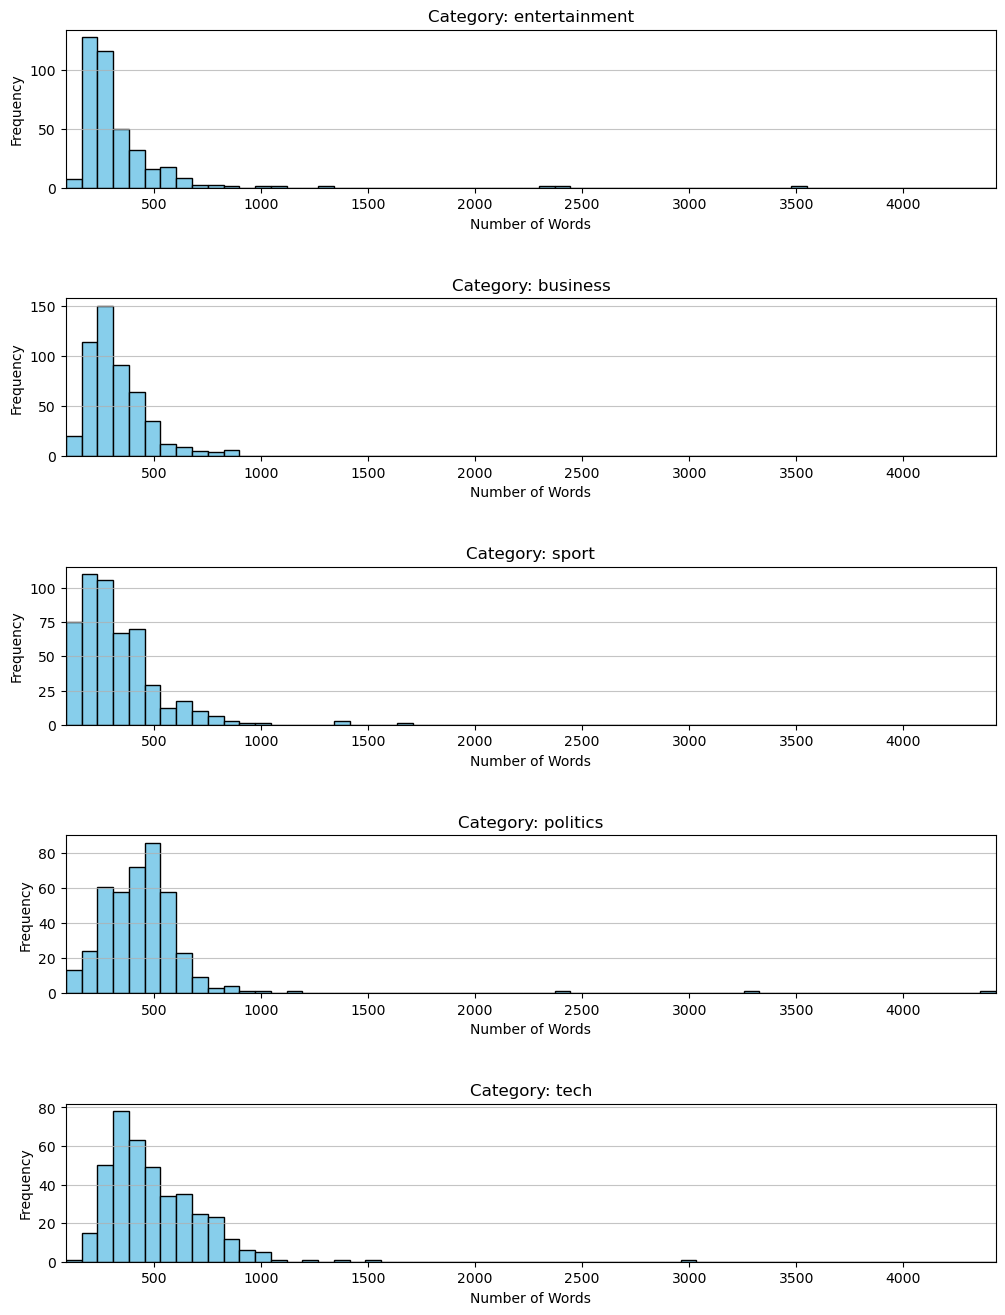

In [3]:
# Calculate the length of each news article (in words)
df['length'] = df['news'].apply(lambda x: len(x.split()))

# List of unique categories in the data
categories = df['category'].unique()

# Determine the number of bins and bin edges for consistent bandwidth
min_length = df['length'].min()
max_length = df['length'].max()
bins = np.linspace(min_length, max_length, 60)  # 60 bins

# Set up the figure with subplots for each category
plt.figure(figsize=(12, 16))

# Create a histogram for each category
for i, category in enumerate(categories, start=1):
    plt.subplot(len(categories), 1, i)
    category_data = df[df['category'] == category]
    plt.hist(category_data['length'], bins=bins, color='skyblue', edgecolor='black')
    plt.title(f'Category: {category}')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.xlim(min_length, max_length)
    plt.grid(axis='y', alpha=0.75)

# Adjust the layout to increase the vertical space between subplots
plt.subplots_adjust(hspace=0.7)  # Increase this value for more space

plt.show()

In [4]:
# Extract the news articles and category columns
X = df['news']

# Convert 'category' to binary labels: 1 for 'tech', 0 for others
y = df['category'].apply(lambda category: 1 if category == 'tech' else 0)

## Naive Bayes Classifier

In [5]:
# Set up the Tf-IDF vectorizer and Multinomial Naive Bayes in a pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('nb', MultinomialNB())
])

# Initialize StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [6]:
# Run cross-validation
accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
predicted = cross_val_predict(pipeline, X, y, cv=cv)

# Calculate metrics
accuracy = accuracy_score(y, predicted)
sensitivity = recall_score(y, predicted)  # true positive rate
specificity = recall_score(y, predicted, pos_label=0)  # true negative rate
conf_matrix = confusion_matrix(y, predicted)

# Create a DataFrame for the confusion matrix with labeled axes
conf_matrix_df = pd.DataFrame(
    conf_matrix, 
    index=['Actual Non-Tech', 'Actual Tech'], 
    columns=['Predicted Non-Tech', 'Predicted Tech']
)

# Output the results
print("Cross-Validated Accuracy Scores:", accuracy_scores)
print(f"Mean Accuracy: {accuracy:.2f}")
print(f"Sensitivity (Recall for 'tech' class): {sensitivity:.2f}")
print(f"Specificity (Recall for 'non-tech' class): {specificity:.2f}")
print("\nConfusion Matrix:\n", conf_matrix_df)

Cross-Validated Accuracy Scores: [0.88539326 0.89662921 0.9011236  0.88988764 0.91011236]
Mean Accuracy: 0.90
Sensitivity (Recall for 'tech' class): 0.43
Specificity (Recall for 'non-tech' class): 1.00

Confusion Matrix:
                  Predicted Non-Tech  Predicted Tech
Actual Non-Tech                1824               0
Actual Tech                     230             171


In [7]:
# Create a DataFrame to store results
results_df = pd.DataFrame({
    'Model': ['Naive Bayes'],
    'Accuracy': [accuracy],
    'Sensitivity': [sensitivity],
    'Specificity': [specificity]
})

# Using tabulate to print the results
print("Model Performance Metrics:")
print(tabulate(results_df, headers='keys', tablefmt='grid'))

Model Performance Metrics:
+----+-------------+------------+---------------+---------------+
|    | Model       |   Accuracy |   Sensitivity |   Specificity |
+====+=============+============+===============+===============+
|  0 | Naive Bayes |   0.896629 |      0.426434 |             1 |
+----+-------------+------------+---------------+---------------+


## k-Nearest Neighbors (KNN) Classifier

### Case 1: Dafault Parameters of KNeighborsClassifier()

In [8]:
# Set up the Tf-IDF vectorizer and k-Nearest Neighbors in a pipeline
knn_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('knn', KNeighborsClassifier(n_neighbors=5))  # Default n_neighbors is 5
])

# Initialize StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
# Run cross-validation
knn_accuracy_scores = cross_val_score(knn_pipeline, X, y, cv=cv, scoring='accuracy')
knn_predicted = cross_val_predict(knn_pipeline, X, y, cv=cv)

# Calculate metrics for KNN
knn_accuracy = accuracy_score(y, knn_predicted)
knn_sensitivity = recall_score(y, knn_predicted)  # true positive rate
knn_specificity = recall_score(y, knn_predicted, pos_label=0)  # true negative rate
knn_conf_matrix = confusion_matrix(y, knn_predicted)

# Create a DataFrame for the confusion matrix with labeled axes
knn_conf_matrix_df = pd.DataFrame(
    knn_conf_matrix,
    index=['Actual Non-Tech', 'Actual Tech'],
    columns=['Predicted Non-Tech', 'Predicted Tech']
)

# Output the results for KNN
print("Cross-Validated Accuracy Scores for KNN:", knn_accuracy_scores)
print(f"Mean Accuracy for KNN: {knn_accuracy:.2f}")
print(f"Sensitivity (Recall for 'tech' class) for KNN: {knn_sensitivity:.2f}")
print(f"Specificity (Recall for 'non-tech' class) for KNN: {knn_specificity:.2f}")
print("\nConfusion Matrix for K-Nearest Neighbors:\n", knn_conf_matrix_df)

Cross-Validated Accuracy Scores for KNN: [0.97977528 0.95730337 0.98202247 0.98202247 0.97303371]
Mean Accuracy for KNN: 0.97
Sensitivity (Recall for 'tech' class) for KNN: 0.94
Specificity (Recall for 'non-tech' class) for KNN: 0.98

Confusion Matrix for K-Nearest Neighbors:
                  Predicted Non-Tech  Predicted Tech
Actual Non-Tech                1793              31
Actual Tech                      25             376


In [10]:
# Store KNN results in a new DataFrame
knn_results = pd.DataFrame({
    'Model': ['K-Nearest Neighbors with defaults'],
    'Accuracy': [knn_accuracy],
    'Sensitivity': [knn_sensitivity],
    'Specificity': [knn_specificity]
})

# Use pd.concat to combine the results
results_df = pd.concat([results_df, knn_results], ignore_index=True)

# Using tabulate to print the results for KNN
print("Model Performance Metrics for KNN:")
print(tabulate(results_df, headers='keys', tablefmt='grid'))

Model Performance Metrics for KNN:
+----+-----------------------------------+------------+---------------+---------------+
|    | Model                             |   Accuracy |   Sensitivity |   Specificity |
+====+===================================+============+===============+===============+
|  0 | Naive Bayes                       |   0.896629 |      0.426434 |      1        |
+----+-----------------------------------+------------+---------------+---------------+
|  1 | K-Nearest Neighbors with defaults |   0.974831 |      0.937656 |      0.983004 |
+----+-----------------------------------+------------+---------------+---------------+


### Case 2: Optimal `k` of KNeighborsClassifier() 

In [11]:
# KNN Pipeline
knn_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('knn', KNeighborsClassifier())  # KNN will be hyperparameter-tuned
])

# Use StratifiedKFold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the parameter grid for KNN
knn_param_grid = {
    'knn__n_neighbors': list(range(1, 21))  # Test values of n_neighbors from 1 to 20
}

# Set up GridSearchCV targeting the KNN pipeline
grid_search = GridSearchCV(knn_pipeline, knn_param_grid, cv=cv, scoring='accuracy')

# Fit the grid search to find the best k
grid_search.fit(X, y)

# Retrieve the best number of neighbors
k_opt = grid_search.best_params_['knn__n_neighbors']
print(f"Optimal number of neighbors: {k_opt}")
print(f"Best cross-validated accuracy: {grid_search.best_score_:.2f}")

Optimal number of neighbors: 19
Best cross-validated accuracy: 0.98


In [12]:
# Set up the best KNN pipeline using the optimal k
best_knn_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('knn', KNeighborsClassifier(n_neighbors=k_opt))
])

# Cross-validated predictions with the best KNN
knn_predicted = cross_val_predict(best_knn_pipeline, X, y, cv=cv)

# Calculate metrics
knn_accuracy = accuracy_score(y, knn_predicted)
knn_sensitivity = recall_score(y, knn_predicted)  # true positive rate for 'tech'
knn_specificity = recall_score(y, knn_predicted, pos_label=0)  # true negative rate for 'non-tech'
knn_conf_matrix = confusion_matrix(y, knn_predicted)

# Create a DataFrame for the confusion matrix with labeled axes
knn_conf_matrix_df = pd.DataFrame(
    knn_conf_matrix,
    index=['Actual Non-Tech', 'Actual Tech'],
    columns=['Predicted Non-Tech', 'Predicted Tech']
)

# Output results
print("Metrics for Optimized KNN:")
print(f"Cross-Validated Accuracy for Optimal K: {knn_accuracy:.2f}")
print(f"Sensitivity (Recall for 'tech' class): {knn_sensitivity:.2f}")
print(f"Specificity (Recall for 'non-tech' class): {knn_specificity:.2f}")
print("\nConfusion Matrix for K-Nearest Neighbors:\n", knn_conf_matrix_df)

# Store KNN results in a DataFrame for comparison
knn_results = pd.DataFrame({
    'Model': [f'K-Nearest Neighbors with k = {k_opt}'],
    'Accuracy': [knn_accuracy],
    'Sensitivity': [knn_sensitivity],
    'Specificity': [knn_specificity]
})

# Assuming results_df already contains results from other models, concatenate the new results
results_df = pd.concat([results_df, knn_results], ignore_index=True)

# Using tabulate to print combined results
print("Model Performance Metrics:")
print(tabulate(results_df, headers='keys', tablefmt='grid'))

Metrics for Optimized KNN:
Cross-Validated Accuracy for Optimal K: 0.98
Sensitivity (Recall for 'tech' class): 0.94
Specificity (Recall for 'non-tech' class): 0.99

Confusion Matrix for K-Nearest Neighbors:
                  Predicted Non-Tech  Predicted Tech
Actual Non-Tech                1799              25
Actual Tech                      25             376
Model Performance Metrics:
+----+-----------------------------------+------------+---------------+---------------+
|    | Model                             |   Accuracy |   Sensitivity |   Specificity |
+====+===================================+============+===============+===============+
|  0 | Naive Bayes                       |   0.896629 |      0.426434 |      1        |
+----+-----------------------------------+------------+---------------+---------------+
|  1 | K-Nearest Neighbors with defaults |   0.974831 |      0.937656 |      0.983004 |
+----+-----------------------------------+------------+---------------+----------

## Logistic Regression

In [13]:
# Set up the Tf-IDF vectorizer and Logistic Regression in a pipeline
logreg_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('logreg', LogisticRegression(max_iter=1000))  # Increase max_iter if convergence issues occur
])

# Initialize StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation
logreg_accuracy_scores = cross_val_score(logreg_pipeline, X, y, cv=cv, scoring='accuracy')
logreg_predicted = cross_val_predict(logreg_pipeline, X, y, cv=cv)

# Calculate metrics for Logistic Regression
logreg_accuracy = accuracy_score(y, logreg_predicted)
logreg_sensitivity = recall_score(y, logreg_predicted)  # true positive rate
logreg_specificity = recall_score(y, logreg_predicted, pos_label=0)  # true negative rate
logreg_conf_matrix = confusion_matrix(y, logreg_predicted)

# Create a DataFrame for the confusion matrix with labeled axes
logreg_conf_matrix_df = pd.DataFrame(
    logreg_conf_matrix,
    index=['Actual Non-Tech', 'Actual Tech'],
    columns=['Predicted Non-Tech', 'Predicted Tech']
)

# Output the results for Logistic Regression
print("Cross-Validated Accuracy Scores for Logistic Regression:", logreg_accuracy_scores)
print(f"Mean Accuracy for Logistic Regression: {logreg_accuracy:.2f}")
print(f"Sensitivity (Recall for 'tech' class) for Logistic Regression: {logreg_sensitivity:.2f}")
print(f"Specificity (Recall for 'non-tech' class) for Logistic Regression: {logreg_specificity:.2f}")
print("\nConfusion Matrix for Logistic Regression:\n", logreg_conf_matrix_df)

# Store Logistic Regression results in a new DataFrame
logreg_results = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'Accuracy': [logreg_accuracy],
    'Sensitivity': [logreg_sensitivity],
    'Specificity': [logreg_specificity]
})

# Use pd.concat to combine the results
results_df = pd.concat([results_df, logreg_results], ignore_index=True)

# Using tabulate to print the results for Logistic Regression
print("\nModel Performance Metrics:")
print(tabulate(results_df, headers='keys', tablefmt='grid'))

Cross-Validated Accuracy Scores for Logistic Regression: [0.94157303 0.94157303 0.94831461 0.94382022 0.96404494]
Mean Accuracy for Logistic Regression: 0.95
Sensitivity (Recall for 'tech' class) for Logistic Regression: 0.71
Specificity (Recall for 'non-tech' class) for Logistic Regression: 1.00

Confusion Matrix for Logistic Regression:
                  Predicted Non-Tech  Predicted Tech
Actual Non-Tech                1824               0
Actual Tech                     116             285

Model Performance Metrics:
+----+-----------------------------------+------------+---------------+---------------+
|    | Model                             |   Accuracy |   Sensitivity |   Specificity |
+====+===================================+============+===============+===============+
|  0 | Naive Bayes                       |   0.896629 |      0.426434 |      1        |
+----+-----------------------------------+------------+---------------+---------------+
|  1 | K-Nearest Neighbors with de

## Support Vector Machine (SVM):

### Case 1: Default Values of `kernel` and `C` Parameters of SVC()

In [14]:
# Set up the Tf-IDF vectorizer and SVM in a pipeline
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('svm', SVC(kernel='rbf', C=1.0))  # Using default values
])

# Initialize StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation
svm_accuracy_scores = cross_val_score(svm_pipeline, X, y, cv=cv, scoring='accuracy')
svm_predicted = cross_val_predict(svm_pipeline, X, y, cv=cv)

# Calculate metrics for SVM
svm_accuracy = accuracy_score(y, svm_predicted)
svm_sensitivity = recall_score(y, svm_predicted)  # true positive rate
svm_specificity = recall_score(y, svm_predicted, pos_label=0)  # true negative rate
svm_conf_matrix = confusion_matrix(y, svm_predicted)

# Create a DataFrame for the confusion matrix with labeled axes
svm_conf_matrix_df = pd.DataFrame(
    svm_conf_matrix,
    index=['Actual Non-Tech', 'Actual Tech'],
    columns=['Predicted Non-Tech', 'Predicted Tech']
)

# Output the results for SVM
print("Cross-Validated Accuracy Scores for SVM:", svm_accuracy_scores)
print(f"Mean Accuracy for SVM: {svm_accuracy:.2f}")
print(f"Sensitivity (Recall for 'tech' class) for SVM: {svm_sensitivity:.2f}")
print(f"Specificity (Recall for 'non-tech' class) for SVM: {svm_specificity:.2f}")
print("\nConfusion Matrix for SVM:\n", svm_conf_matrix_df)

# Store SVM results in a new DataFrame
svm_results = pd.DataFrame({
    'Model': ["SVM with defaults"],
    'Accuracy': [svm_accuracy],
    'Sensitivity': [svm_sensitivity],
    'Specificity': [svm_specificity]
})

# Use pd.concat to combine the results
results_df = pd.concat([results_df, svm_results], ignore_index=True)

# Using tabulate to print the results for SVM
print("\nModel Performance Metrics:")
print(tabulate(results_df, headers='keys', tablefmt='grid'))

Cross-Validated Accuracy Scores for SVM: [0.97303371 0.97303371 0.97752809 0.97078652 0.98202247]
Mean Accuracy for SVM: 0.98
Sensitivity (Recall for 'tech' class) for SVM: 0.87
Specificity (Recall for 'non-tech' class) for SVM: 1.00

Confusion Matrix for SVM:
                  Predicted Non-Tech  Predicted Tech
Actual Non-Tech                1820               4
Actual Tech                      51             350

Model Performance Metrics:
+----+-----------------------------------+------------+---------------+---------------+
|    | Model                             |   Accuracy |   Sensitivity |   Specificity |
+====+===================================+============+===============+===============+
|  0 | Naive Bayes                       |   0.896629 |      0.426434 |      1        |
+----+-----------------------------------+------------+---------------+---------------+
|  1 | K-Nearest Neighbors with defaults |   0.974831 |      0.937656 |      0.983004 |
+----+--------------------

### Case 2: Optimal `kernel` and `C` Parameters of SVC()

In [15]:
# Set up the TF-IDF vectorizer and SVC in a pipeline
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('svm', SVC())  # Allow SVM settings such as kernel to be tuned
])

# Use StratifiedKFold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the parameter grid for SVM
svm_param_grid = {
    'svm__C': [0.1, 1, 10],  # Regularization parameter
    'svm__kernel': ['linear', 'rbf', 'poly'],  # Test different kernels
}

# Set up GridSearchCV targeting the SVM pipeline
grid_search_svm = GridSearchCV(svm_pipeline, svm_param_grid, cv=cv, scoring='accuracy')

# Fit the grid search to find the best SVM parameters
grid_search_svm.fit(X, y)

# Retrieve the best parameters for SVM
svm_best_params = grid_search_svm.best_params_
print(f"Optimal parameters for SVM: {svm_best_params}")
print(f"Best cross-validated accuracy for SVM: {grid_search_svm.best_score_:.2f}")

# Set up the best SVM pipeline using the optimal parameters
best_svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('svm', SVC(
        C=svm_best_params['svm__C'],
        kernel=svm_best_params['svm__kernel'])
    )
])

# Cross-validated predictions with the best SVM
svm_predicted = cross_val_predict(best_svm_pipeline, X, y, cv=cv)

# Calculate metrics
svm_accuracy = accuracy_score(y, svm_predicted)
svm_sensitivity = recall_score(y, svm_predicted)  # true positive rate for 'tech'
svm_specificity = recall_score(y, svm_predicted, pos_label=0)  # true negative rate for 'non-tech'
svm_conf_matrix = confusion_matrix(y, svm_predicted)

# Create a DataFrame for the confusion matrix with labeled axes
svm_conf_matrix_df = pd.DataFrame(
    svm_conf_matrix,
    index=['Actual Non-Tech', 'Actual Tech'],
    columns=['Predicted Non-Tech', 'Predicted Tech']
)

# Output results
print("Metrics for Optimized SVM:")
print(f"Cross-Validated Accuracy for Optimal SVM: {svm_accuracy:.2f}")
print(f"Sensitivity (Recall for 'tech' class): {svm_sensitivity:.2f}")
print(f"Specificity (Recall for 'non-tech' class): {svm_specificity:.2f}")
print("\nConfusion Matrix for SVM:\n", svm_conf_matrix_df)

# Store SVM results in a DataFrame for comparison
svm_results = pd.DataFrame({
    'Model': [f'SVM with {svm_best_params}'],
    'Accuracy': [svm_accuracy],
    'Sensitivity': [svm_sensitivity],
    'Specificity': [svm_specificity]
})

# Assuming results_df already contains results from other models, concatenate the new results
results_df = pd.concat([results_df, svm_results], ignore_index=True)

# Using tabulate to print combined results
print("Model Performance Metrics:")
print(tabulate(results_df, headers='keys', tablefmt='grid'))

Optimal parameters for SVM: {'svm__C': 10, 'svm__kernel': 'linear'}
Best cross-validated accuracy for SVM: 0.99
Metrics for Optimized SVM:
Cross-Validated Accuracy for Optimal SVM: 0.99
Sensitivity (Recall for 'tech' class): 0.97
Specificity (Recall for 'non-tech' class): 1.00

Confusion Matrix for SVM:
                  Predicted Non-Tech  Predicted Tech
Actual Non-Tech                1817               7
Actual Tech                      13             388
Model Performance Metrics:
+----+--------------------------------------------------+------------+---------------+---------------+
|    | Model                                            |   Accuracy |   Sensitivity |   Specificity |
+====+==================================================+============+===============+===============+
|  0 | Naive Bayes                                      |   0.896629 |      0.426434 |      1        |
+----+--------------------------------------------------+------------+---------------+-------------

## Random Forest

### Case 1: Default Parameters of RandomForestClassifier()

In [16]:
# Set up the TF-IDF vectorizer and Random Forest in a pipeline
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('rf', RandomForestClassifier(n_estimators=100,
                                  max_depth=None,
                                  criterion='gini',
                                  max_features='sqrt',
                                  random_state=42))  # Default parameters
])

# Initialize StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation
rf_accuracy_scores = cross_val_score(rf_pipeline, X, y, cv=cv, scoring='accuracy')
rf_predicted = cross_val_predict(rf_pipeline, X, y, cv=cv)

# Calculate metrics for Random Forest
rf_accuracy = accuracy_score(y, rf_predicted)
rf_sensitivity = recall_score(y, rf_predicted)  # true positive rate
rf_specificity = recall_score(y, rf_predicted, pos_label=0)  # true negative rate
rf_conf_matrix = confusion_matrix(y, rf_predicted)

# Create a DataFrame for the confusion matrix with labeled axes
rf_conf_matrix_df = pd.DataFrame(
    rf_conf_matrix,
    index=['Actual Non-Tech', 'Actual Tech'],
    columns=['Predicted Non-Tech', 'Predicted Tech']
)

# Output the results for Random Forest
print("Cross-Validated Accuracy Scores for Random Forest:", rf_accuracy_scores)
print(f"Mean Accuracy for Random Forest: {rf_accuracy:.2f}")
print(f"Sensitivity (Recall for 'tech' class) for Random Forest: {rf_sensitivity:.2f}")
print(f"Specificity (Recall for 'non-tech' class) for Random Forest: {rf_specificity:.2f}")
print("\nConfusion Matrix for Random Forest:\n", rf_conf_matrix_df)

# Store Random Forest results in a new DataFrame
rf_results = pd.DataFrame({
    'Model': [f"Random Forest with defaults"],
    'Accuracy': [rf_accuracy],
    'Sensitivity': [rf_sensitivity],
    'Specificity': [rf_specificity]
})

# Assuming results_df already contains results from other models, concatenate the new results
results_df = pd.concat([results_df, rf_results], ignore_index=True)

# Using tabulate to print the results for Random Forest
print("\nModel Performance Metrics:")
print(tabulate(results_df, headers='keys', tablefmt='grid'))

Cross-Validated Accuracy Scores for Random Forest: [0.97303371 0.97303371 0.98426966 0.9752809  0.98651685]
Mean Accuracy for Random Forest: 0.98
Sensitivity (Recall for 'tech' class) for Random Forest: 0.89
Specificity (Recall for 'non-tech' class) for Random Forest: 1.00

Confusion Matrix for Random Forest:
                  Predicted Non-Tech  Predicted Tech
Actual Non-Tech                1820               4
Actual Tech                      44             357

Model Performance Metrics:
+----+--------------------------------------------------+------------+---------------+---------------+
|    | Model                                            |   Accuracy |   Sensitivity |   Specificity |
+====+==================================================+============+===============+===============+
|  0 | Naive Bayes                                      |   0.896629 |      0.426434 |      1        |
+----+--------------------------------------------------+------------+---------------+------

### Case 2: Optimal `rf__criterion`,  `rf__criterion`, `rf__max_features`, and `rf__max_depth` Parameters of RandomForestClassifier()

In [17]:
# Set up the TF-IDF vectorizer and Random Forest in a pipeline
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('rf', RandomForestClassifier(random_state=42))
])

# Use StratifiedKFold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the parameter grid for Random Forest
rf_param_grid = {
    #'rf__n_estimators': [50, 100, 200],           # Test various numbers of trees
    'rf__criterion': ['gini', 'entropy'],         # Test different criteria
    'rf__max_features': ['sqrt', 'log2', None],   # Number of features to consider at every split
    #'rf__max_depth': [None, 10, 20, 30]           # Maximum depth of the trees
}

# Set up GridSearchCV targeting the Random Forest pipeline
grid_search_rf = GridSearchCV(rf_pipeline, rf_param_grid, cv=cv, scoring='accuracy')

# Fit the grid search to find the best Random Forest parameters
grid_search_rf.fit(X, y)

# Retrieve the best parameters for Random Forest
rf_best_params = grid_search_rf.best_params_
print(f"Optimal parameters for Random Forest: {rf_best_params}")
print(f"Best cross-validated accuracy for Random Forest: {grid_search_rf.best_score_:.2f}")

# Set up the best Random Forest pipeline using the optimal parameters
best_rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('rf', RandomForestClassifier(
        criterion=rf_best_params['rf__criterion'],
        max_features=rf_best_params['rf__max_features'],
        random_state=42))
])

# Cross-validated predictions with the best Random Forest
rf_predicted = cross_val_predict(best_rf_pipeline, X, y, cv=cv)

# Calculate metrics
rf_accuracy = accuracy_score(y, rf_predicted)
rf_sensitivity = recall_score(y, rf_predicted)  # true positive rate for 'tech'
rf_specificity = recall_score(y, rf_predicted, pos_label=0)  # true negative rate for 'non-tech'
rf_conf_matrix = confusion_matrix(y, rf_predicted)

# Create a DataFrame for the confusion matrix with labeled axes
rf_conf_matrix_df = pd.DataFrame(
    rf_conf_matrix,
    index=['Actual Non-Tech', 'Actual Tech'],
    columns=['Predicted Non-Tech', 'Predicted Tech']
)

# Output results
print("Metrics for Optimized Random Forest:")
print(f"Cross-Validated Accuracy for Optimal Random Forest: {rf_accuracy:.2f}")
print(f"Sensitivity (Recall for 'tech' class): {rf_sensitivity:.2f}")
print(f"Specificity (Recall for 'non-tech' class): {rf_specificity:.2f}")
print("\nConfusion Matrix for Random Forest:\n", rf_conf_matrix_df)

# Store Random Forest results in a DataFrame for comparison
rf_results = pd.DataFrame({
    'Model': [f'Random Forest with {rf_best_params}'],
    'Accuracy': [rf_accuracy],
    'Sensitivity': [rf_sensitivity],
    'Specificity': [rf_specificity]
})

# Assuming results_df already contains results from other models, concatenate the new results
results_df = pd.concat([results_df, rf_results], ignore_index=True)

# Using tabulate to print combined results
print("Model Performance Metrics:")
print(tabulate(results_df, headers='keys', tablefmt='grid'))

Optimal parameters for Random Forest: {'rf__criterion': 'gini', 'rf__max_features': 'sqrt'}
Best cross-validated accuracy for Random Forest: 0.98
Metrics for Optimized Random Forest:
Cross-Validated Accuracy for Optimal Random Forest: 0.98
Sensitivity (Recall for 'tech' class): 0.89
Specificity (Recall for 'non-tech' class): 1.00

Confusion Matrix for Random Forest:
                  Predicted Non-Tech  Predicted Tech
Actual Non-Tech                1820               4
Actual Tech                      44             357
Model Performance Metrics:
+----+--------------------------------------------------------------------------+------------+---------------+---------------+
|    | Model                                                                    |   Accuracy |   Sensitivity |   Specificity |
+====+==========================================================================+============+===============+===============+
|  0 | Naive Bayes                                                

## Model Comparison

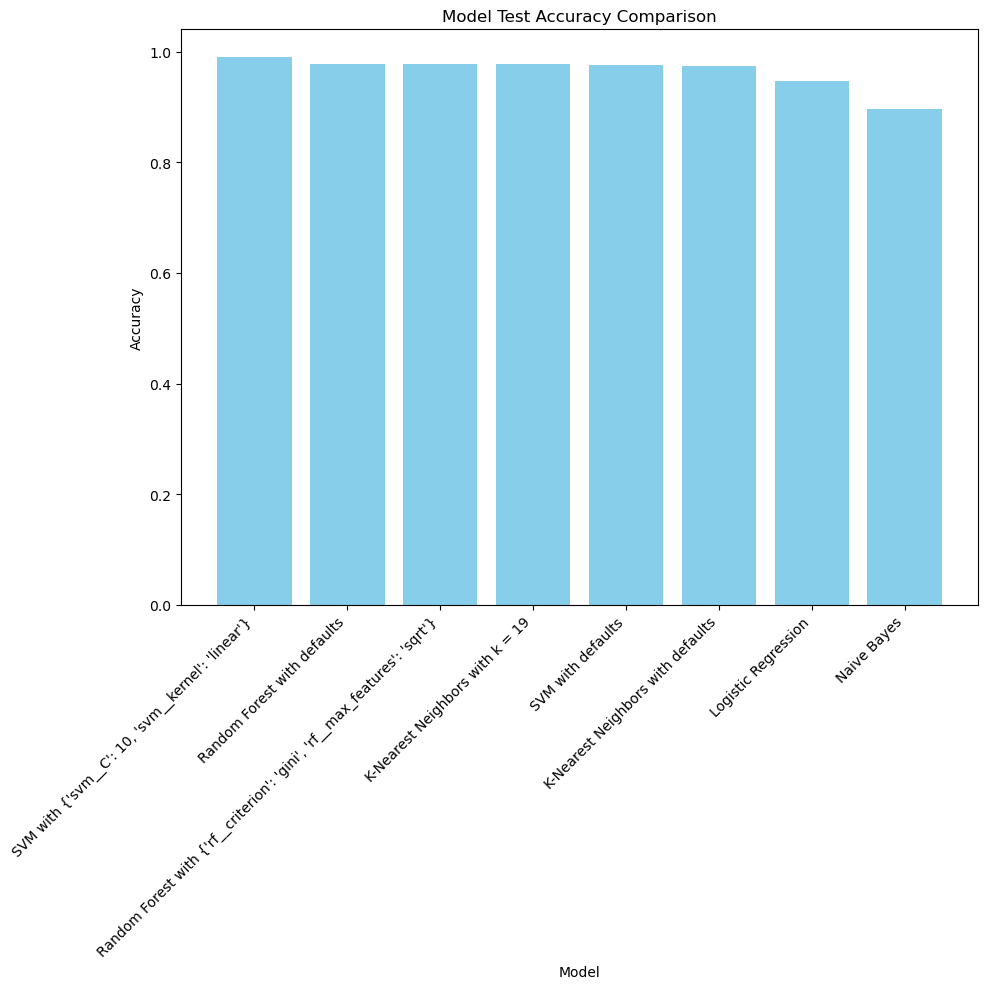

The best-performing model is SVM with {'svm__C': 10, 'svm__kernel': 'linear'} with an accuracy of 0.99


In [18]:
# Sort the DataFrame by Accuracy in descending order
results_df_sorted = results_df.sort_values(by='Accuracy', ascending=False)

# Create a bar chart for model accuracy
plt.figure(figsize=(10, 10))
plt.bar(results_df_sorted['Model'], results_df_sorted['Accuracy'], color='skyblue')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Test Accuracy Comparison')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Display the plot
plt.show()

# Identify and print the best-performing model based on accuracy
best_model = results_df_sorted.iloc[0]
print(f"The best-performing model is {best_model['Model']} with an accuracy of {best_model['Accuracy']:.2f}")